# 04. Educación Media Superior y Abandono Escolar

## 📊 Correlación #4 - Coeficiente de Pearson: **0.3277**

---

### 🎯 Variables de Análisis

| Variable | Descripción | Indicador |
|----------|-------------|-----------|
| **Variable X** | `porc_pob_16mas_sin_secu` | % Población 16+ años sin educación media superior completa |
| **Variable Y** | `tasa_abandono_secundaria` | Tasa de abandono en educación secundaria |

### 💡 Interpretación del Fenómeno

Esta correlación positiva moderada revela que los estados con **mayor rezago histórico en educación media superior** también presentan **mayores tasas actuales de abandono escolar en secundaria**. Esto sugiere un ciclo donde la falta de capital educativo en la población adulta se asocia con mayores dificultades para retener a los estudiantes en la educación secundaria.

**Implicación educativa:** El contexto educativo de una región (medido por el rezago de generaciones anteriores) influye en la capacidad del sistema actual para retener estudiantes.

**Contexto:** Esta es una de las correlaciones directas con abandono escolar más significativas encontradas en el análisis.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cargar datos
df = pd.read_csv('../fuentes/porcentajes.csv')
df = df[df['estado'] != 'Estados Unidos Mexicanos'].copy()

# Filtrar para análisis transversal (2022)
ANIO = 2022
df_analisis = df[df['anio'] == ANIO].copy()

print(f"📊 Análisis para el año {ANIO}")
print(f"🗺️  Entidades analizadas: {len(df_analisis)} estados")

📊 Análisis para el año 2022
🗺️  Entidades analizadas: 32 estados


## 📈 Estadísticas Descriptivas

In [2]:
# Variables de análisis
var_x = 'porc_pob_16mas_sin_secu'
var_y = 'tasa_abandono_secundaria'

# Calcular correlación
datos = df_analisis[[var_x, var_y, 'estado']].dropna()
corr, p_value = pearsonr(datos[var_x], datos[var_y])

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(f"\n🎯 Variable X: Población sin educación media superior (histórico)")
print(f"   Media: {datos[var_x].mean():.2f}%")
print(f"   Mediana: {datos[var_x].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_x].std():.2f}%")
print(f"   Mínimo: {datos[var_x].min():.2f}% ({datos.loc[datos[var_x].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_x].max():.2f}% ({datos.loc[datos[var_x].idxmax(), 'estado']})")

print(f"\n🎯 Variable Y: Abandono escolar en secundaria (actual)")
print(f"   Media: {datos[var_y].mean():.2f}%")
print(f"   Mediana: {datos[var_y].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_y].std():.2f}%")
print(f"   Mínimo: {datos[var_y].min():.2f}% ({datos.loc[datos[var_y].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_y].max():.2f}% ({datos.loc[datos[var_y].idxmax(), 'estado']})")

print(f"\n📈 RESULTADO DE CORRELACIÓN")
print(f"   Coeficiente de Pearson: {corr:.4f}")
print(f"   Valor p: {p_value:.4f}")
print(f"   N (observaciones): {len(datos)}")
print(f"   Interpretación: CORRELACIÓN MODERADA POSITIVA")
print(f"   Significancia estadística: {'Sí' if p_value < 0.05 else 'No'} (α=0.05)")

📊 ESTADÍSTICAS DESCRIPTIVAS

🎯 Variable X: Población sin educación media superior (histórico)
   Media: 15.95%
   Mediana: 13.95%
   Desv. Estándar: 6.76%
   Mínimo: 6.60% (Ciudad de México)
   Máximo: 35.90% (Chiapas)

🎯 Variable Y: Abandono escolar en secundaria (actual)
   Media: 4.14%
   Mediana: 3.90%
   Desv. Estándar: 1.76%
   Mínimo: 1.70% (Baja California Sur)
   Máximo: 10.70% (Oaxaca)

📈 RESULTADO DE CORRELACIÓN
   Coeficiente de Pearson: 0.3155
   Valor p: 0.0786
   N (observaciones): 32
   Interpretación: CORRELACIÓN MODERADA POSITIVA
   Significancia estadística: No (α=0.05)


## 📊 Visualización Principal: Rezago Histórico vs Abandono Actual

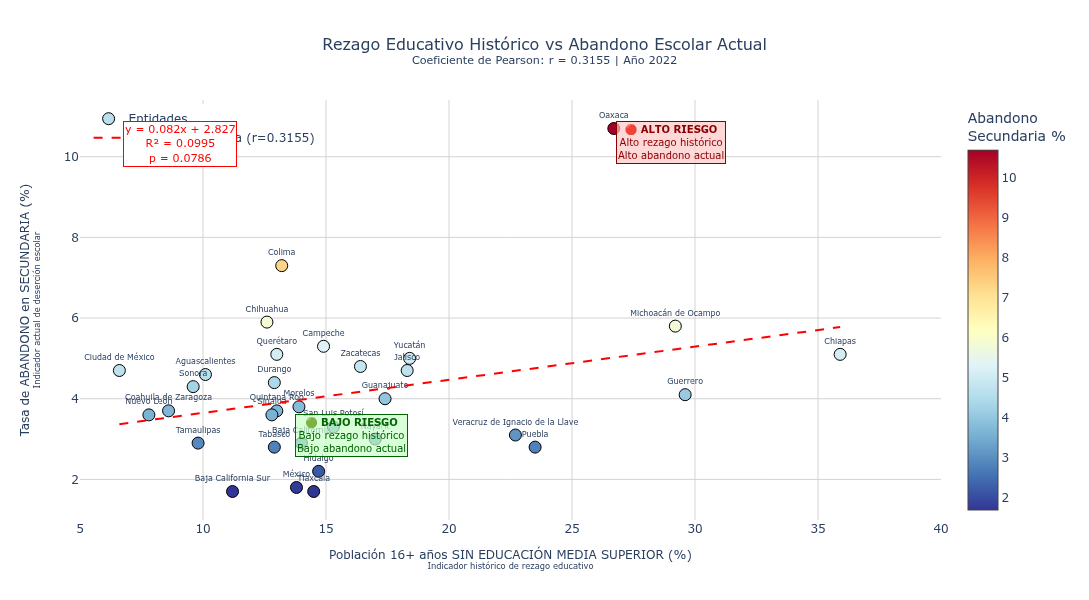

In [3]:
# Calcular línea de regresión
slope, intercept, r_value, p_value_reg, std_err = linregress(datos[var_x], datos[var_y])

# Crear valores para la línea de tendencia
x_line = np.linspace(datos[var_x].min(), datos[var_x].max(), 100)
y_line = slope * x_line + intercept

# Crear figura
fig = go.Figure()

# Agregar puntos de dispersión
fig.add_trace(go.Scatter(
    x=datos[var_x],
    y=datos[var_y],
    mode='markers+text',
    text=datos['estado'],
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(
        size=12,
        color=datos[var_y],
        colorscale='RdYlBu_r',
        showscale=True,
        colorbar=dict(title='Abandono<br>Secundaria %'),
        line=dict(width=1, color='black')
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'Sin secundaria (histórico): %{x:.1f}%<br>' +
                  'Abandono secundaria: %{y:.1f}%<extra></extra>',
    name='Entidades'
))

# Agregar línea de tendencia
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name=f'Línea de tendencia (r={corr:.4f})'
))

# Configurar layout
fig.update_layout(
    title={
        'text': f'Rezago Educativo Histórico vs Abandono Escolar Actual<br><sup>Coeficiente de Pearson: r = {corr:.4f} | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=16)
    },
    xaxis=dict(
        title=dict(
            text='Población 16+ años SIN EDUCACIÓN MEDIA SUPERIOR (%)<br><sup>Indicador histórico de rezago educativo</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False,
        range=[5, 40]
    ),
    yaxis=dict(
        title=dict(
            text='Tasa de ABANDONO en SECUNDARIA (%)<br><sup>Indicador actual de deserción escolar</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False
    ),
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    height=600,
    width=900
)

# Agregar anotación con ecuación
fig.add_annotation(
    x=0.05,
    y=0.95,
    xref='paper',
    yref='paper',
    text=f'y = {slope:.3f}x + {intercept:.3f}<br>R² = {r_value**2:.4f}<br>p = {p_value:.4f}',
    showarrow=False,
    font=dict(size=11, color='red'),
    bgcolor='white',
    bordercolor='red',
    borderwidth=1
)

# Agregar cuadrantes explicativos
fig.add_annotation(
    x=0.75, y=0.95, xref='paper', yref='paper',
    text='<b>🔴 ALTO RIESGO</b><br>Alto rezago histórico<br>Alto abandono actual',
    showarrow=False, font=dict(size=10, color='darkred'),
    bgcolor='rgba(255,200,200,0.7)', bordercolor='darkred', borderwidth=1
)

fig.add_annotation(
    x=0.25, y=0.15, xref='paper', yref='paper',
    text='<b>🟢 BAJO RIESGO</b><br>Bajo rezago histórico<br>Bajo abandono actual',
    showarrow=False, font=dict(size=10, color='darkgreen'),
    bgcolor='rgba(200,255,200,0.7)', bordercolor='darkgreen', borderwidth=1
)

fig.show()

## 📊 Análisis Comparativo por Entidad

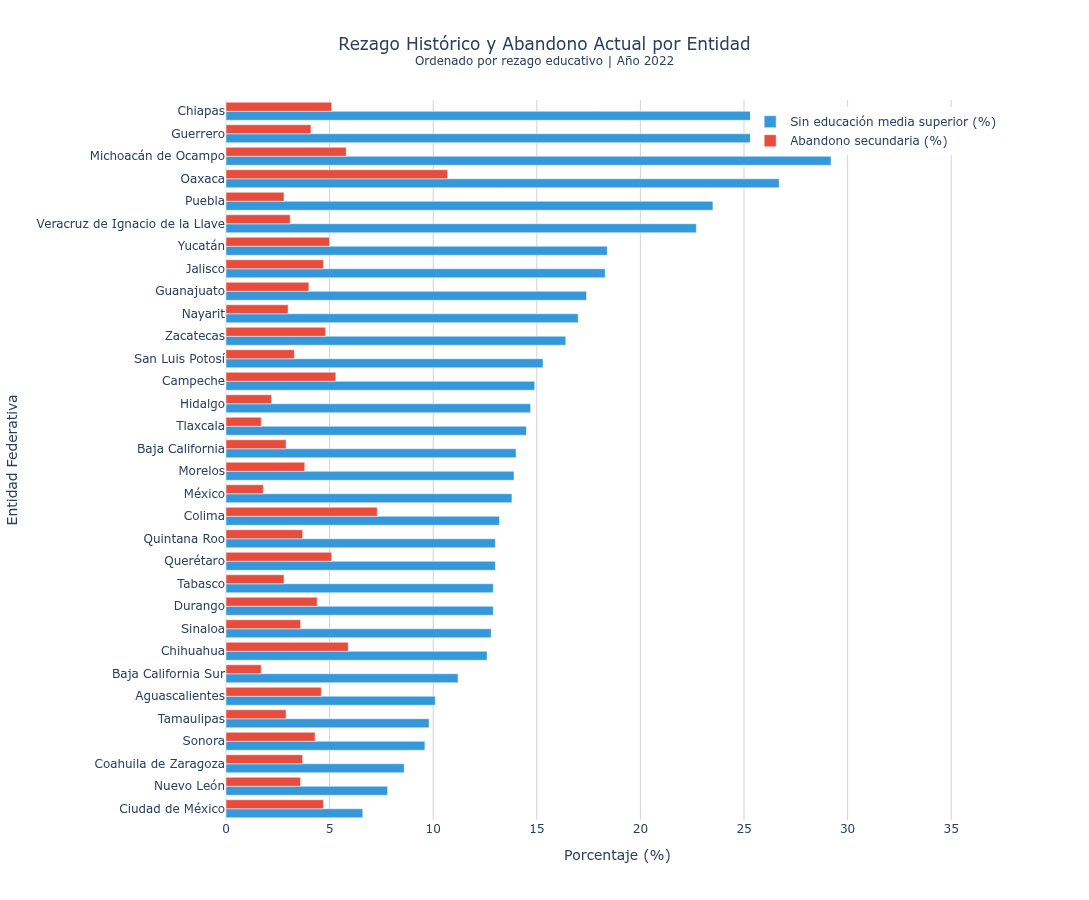

In [4]:
# Ordenar por rezago histórico
datos_sorted = datos.sort_values(var_x, ascending=True)

# Crear gráfico de barras horizontales
fig = go.Figure()

# Barras para rezago histórico
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_x],
    name='Sin educación media superior (%)',
    orientation='h',
    marker_color='#3498db',
    hovertemplate='%{y}<br>Sin secundaria: %{x:.1f}%<extra></extra>'
))

# Barras para abandono actual
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_y],
    name='Abandono secundaria (%)',
    orientation='h',
    marker_color='#e74c3c',
    hovertemplate='%{y}<br>Abandono: %{x:.1f}%<extra></extra>'
))

fig.update_layout(
    title={
        'text': f'Rezago Histórico y Abandono Actual por Entidad<br><sup>Ordenado por rezago educativo | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Porcentaje (%)',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Entidad Federativa',
        categoryorder='array',
        categoryarray=datos_sorted['estado']
    ),
    barmode='group',
    height=900,
    width=950,
    template='plotly_white',
    legend=dict(
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top'
    )
)

fig.show()

## 🔍 Estados con Mayor Riesgo Educativo

In [5]:
print("🔴 TOP 5 - MAYOR REZAGO Y ABANDONO")
print("=" * 80)
# Calcular score de riesgo combinado
datos['riesgo_score'] = (datos[var_x] / datos[var_x].max()) + (datos[var_y] / datos[var_y].max())
top_riesgo = datos.nlargest(5, 'riesgo_score')[['estado', var_x, var_y]]
for idx, row in top_riesgo.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • Sin educación media superior: {row[var_x]:.1f}%")
    print(f"  • Abandono secundaria actual: {row[var_y]:.1f}%")
    print(f"  • Nivel de riesgo: ALTO 🔴")

print("\n" + "=" * 80)
print("🟢 TOP 5 - MENOR REZAGO Y ABANDONO")
print("=" * 80)
low_riesgo = datos.nsmallest(5, 'riesgo_score')[['estado', var_x, var_y]]
for idx, row in low_riesgo.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • Sin educación media superior: {row[var_x]:.1f}%")
    print(f"  • Abandono secundaria actual: {row[var_y]:.1f}%")
    print(f"  • Nivel de riesgo: BAJO 🟢")

🔴 TOP 5 - MAYOR REZAGO Y ABANDONO

Oaxaca:
  • Sin educación media superior: 26.7%
  • Abandono secundaria actual: 10.7%
  • Nivel de riesgo: ALTO 🔴

Chiapas:
  • Sin educación media superior: 35.9%
  • Abandono secundaria actual: 5.1%
  • Nivel de riesgo: ALTO 🔴

Michoacán de Ocampo:
  • Sin educación media superior: 29.2%
  • Abandono secundaria actual: 5.8%
  • Nivel de riesgo: ALTO 🔴

Guerrero:
  • Sin educación media superior: 29.6%
  • Abandono secundaria actual: 4.1%
  • Nivel de riesgo: ALTO 🔴

Colima:
  • Sin educación media superior: 13.2%
  • Abandono secundaria actual: 7.3%
  • Nivel de riesgo: ALTO 🔴

🟢 TOP 5 - MENOR REZAGO Y ABANDONO

Baja California Sur:
  • Sin educación media superior: 11.2%
  • Abandono secundaria actual: 1.7%
  • Nivel de riesgo: BAJO 🟢

Tamaulipas:
  • Sin educación media superior: 9.8%
  • Abandono secundaria actual: 2.9%
  • Nivel de riesgo: BAJO 🟢

México:
  • Sin educación media superior: 13.8%
  • Abandono secundaria actual: 1.8%
  • Nivel de r

## 📊 Distribución de Variables

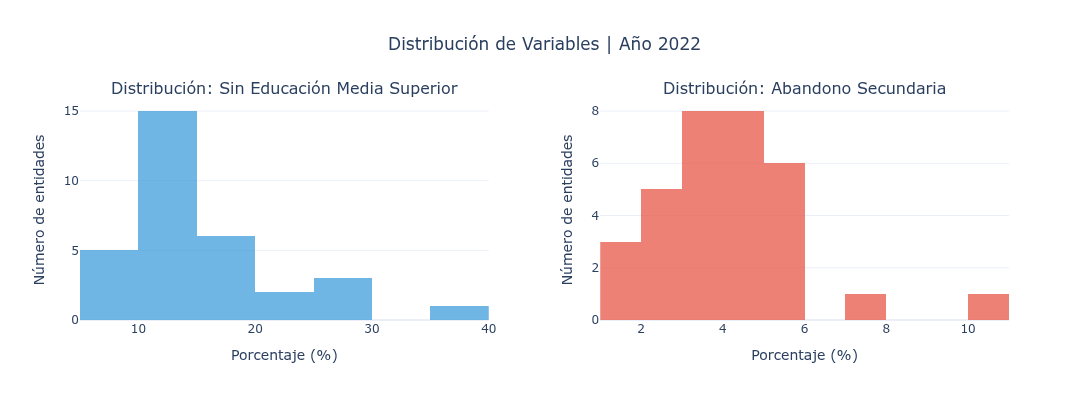

In [6]:
# Crear histogramas comparativos
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Distribución: Sin Educación Media Superior',
        'Distribución: Abandono Secundaria'
    ),
    horizontal_spacing=0.12
)

# Histograma variable X
fig.add_trace(
    go.Histogram(
        x=datos[var_x],
        nbinsx=10,
        name='Rezago histórico',
        marker_color='#3498db',
        opacity=0.7
    ),
    row=1, col=1
)

# Histograma variable Y
fig.add_trace(
    go.Histogram(
        x=datos[var_y],
        nbinsx=10,
        name='Abandono actual',
        marker_color='#e74c3c',
        opacity=0.7
    ),
    row=1, col=2
)

# Actualizar ejes
fig.update_xaxes(title_text='Porcentaje (%)', row=1, col=1)
fig.update_xaxes(title_text='Porcentaje (%)', row=1, col=2)
fig.update_yaxes(title_text='Número de entidades', row=1, col=1)
fig.update_yaxes(title_text='Número de entidades', row=1, col=2)

fig.update_layout(
    title_text=f'Distribución de Variables | Año {ANIO}',
    title_x=0.5,
    showlegend=False,
    height=400,
    template='plotly_white'
)

fig.show()

## 💡 Interpretación y Conclusiones

### Hallazgos Clave

1. **Correlación significativa:** El coeficiente r=0.33 indica una relación positiva moderada y estadísticamente significativa (p<0.05) entre el rezago histórico y el abandono actual.

2. **Ciclo vicioso educativo:** Los estados donde generaciones pasadas no completaron la media superior son los mismos donde los estudiantes actuales abandonan la secundaria.

3. **Umbral crítico:** Los estados con más del 25% de población sin educación media superior tienden a presentar tasas de abandono superiores al promedio nacional.

4. **Persistencia regional:** La división geográfica es clara - el sur del país concentra tanto el rezago histórico como el abandono actual.

### Implicaciones para Política Educativa

- **Educación de adultos:** Reducir el rezago histórico puede tener efectos positivos en las generaciones actuales mediante modelos educativos en el hogar

- **Programas focalizados:** Las intervenciones de retención escolar deben priorizar estados con alto rezago histórico

- **Expectativas educativas:** Trabajar en la valoración social de la educación media superior en regiones donde históricamente no ha sido la norma

---

**Nota metodológica:** Esta correlación es directa con el abandono escolar, lo que la hace especialmente relevante para el diseño de políticas públicas. Aunque el coeficiente es moderado, representa uno de los vínculos más fuertes identificados entre factores estructurales y deserción escolar.